In [1]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

import stratification_and_vert_grids as strat

%matplotlib inline

# Set up script for QGN model
Set up and generate input deck files for QGN simulations by defining/selecting the following:

- Save directory path / run name
- Column depth, number of vertical layers, and select or define a stratification
- Select a vertical grid scheme
- Define or select a background mean flow


In [10]:
savedir = '../RUN_NAME/' # set directory to save generated input files
os.makedirs(savedir,exist_ok=True)

if savedir[-1] != '/': savedir += '/'

## Vertical stratification profile and grid

### Set background stratification profile

In [3]:
Htot = 4.8e3 ## set domain height (in meters); not read by QGN and should also be set in parameters.f90
nz   = 32    ## set number of vertical layers

## define stratification as buoyancy frequency; func N2 is N^2(z)/f with nondimensionalized depth z=1-zdim/H in [0,1]

# synthetic 'realistic' ocean stratification with subsurface pycnocline
def N2(t):
    return (0.04 + 0.22*t + 0.045*strat.cauchy_dist(t,0.97,0.03))**2*1e4

# some idealized options: constant and exponential
# def N2(t):
#     return t/t

# def N2(t):
#     return np.exp(8*t)/np.exp(8)

### Define vertical grid

In [4]:
# Pick a scheme to define vertical grid interfaces (zi)

##################################### Analytic grids ##############################################

## Use an equispaced grid in alpha = 0: geopotential, 1: Charney, or 2: isopycnal coordinates (or any alpha in [0,2])
# alpha = 1
# zi = strat.get_equispaced_alpha_grid(nz,alpha,N2)

# Use a half-Chebyshev (bottom boundary) or full Chebyshev grid in a given alpha coordinate with
# alpha = 0: geopotential, 1: Charney, or 2: isopycnal (or any alpha in [0,2])
alpha = 1
zi = strat.get_half_Chebyshev_alpha_grid(nz,alpha,N2)
# zi = strat.get_full_Chebyshev_alpha_grid(nz,alpha,N2)

# ## Use extrema or roots of highest / second highest order resolved baroclinic mode for grid interfaces
# zi = strat.get_extrema_grid(nz,N2)
# zi = strat.get_roots_grid(nz,N2)

########################### Pre-defined grids from climate ocean models ###########################

## Use a geopotential grid from MOM6; prescribed and will have a fixed number of layers over the specificed column depth Htot
# zi = strat.get_MOM6_zGrid(Htot)
# nz = len(h)

## Use isopycnal density layers specified as part of hybrid grid in OM4
## Will likely need tuned and requires realistic range of densities; currently adjusted for given 'realistic' stratification
# zi = strat.get_OM4_isoGrid(Htot,N2,f = 1e-4,beta = 2e-11, rho_top=1025., shft = 9)
# nz = len(h)

########################### Compute grid cell centers and heights ###########################
zc = (zi[1:]+zi[:-1])/2.
h = zi[1:]-zi[:-1]

### Preview stratification and grid (optional)

Text(0, 0.5, 'Depth $1-z/H$')

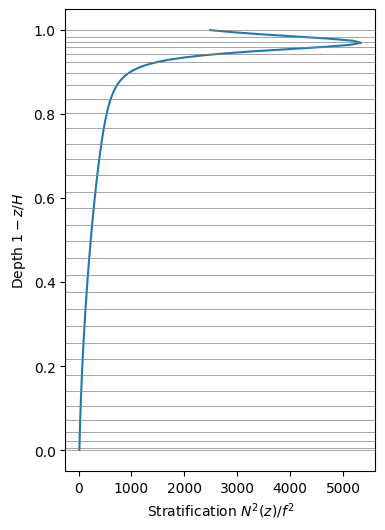

In [5]:
zs = np.linspace(0,1,200)

plt.figure(figsize=(4,6))
plt.plot(N2(zs),zs)

for z in zi:
    plt.axhline(z,color='grey',lw=0.5)

plt.xlabel(r'Stratification $N^2(z)/f^2$')
plt.ylabel(r'Depth $1-z/H$')

## Set background mean flow

Prescribe a background mean velocity profile, $\overline{U}(z)$, with corresponding PV gradient profile, $\overline{q}_y$

In [6]:
def get_Phillips_background(zi,h,N2):

    _, vecs, L = strat.get_modes(zi,h,N2)
    
    first_bc_mode = vecs[:,1]
    first_bc_mode /= first_bc_mode[-1]
    
    u_bar = first_bc_mode

    qy_bar = -(1/Htot**2)*L@u_bar
    
    return u_bar, qy_bar

def get_Ocean_Charney_background(zi,h,N2):

    _, _, L = strat.get_modes(zi,h,N2)

    L_oc = L[:-1,1:]
    oc_profile = np.linalg.solve(L_oc,np.ones(nz-1))
    oc_profile = np.concatenate((np.zeros(1),oc_profile))
    oc_profile /= oc_profile[-1]

    u_bar = oc_profile

    qy_bar = -(1/Htot**2)*L@u_bar
    
    return u_bar, qy_bar

def get_combination_background(zi,h,N2,oc_frac,bc_frac):

    _, vecs, L = strat.get_modes(zi,h,N2)
    
    first_bc_mode = vecs[:,1]
    first_bc_mode /= first_bc_mode[-1]

    L_oc = L[:-1,1:]
    oc_profile = np.linalg.solve(L_oc,np.ones(nz-1))
    oc_profile = np.concatenate((np.zeros(1),oc_profile))
    oc_profile /= oc_profile[-1]

    u_bar = bc_frac*first_bc_mode - oc_frac*oc_profile

    qy_bar = -(1/Htot**2)*L@u_bar

    return u_bar, qy_bar


In [7]:
# no flow or define something else
# u_bar, qy_bar = np.zeros(len(zc)),np.zeros(len(zc))

# # Compute background for Phillips and Charney or combined cases using background stratification
u_bar, qy_bar = get_Phillips_background(zi,h,N2)
# u_bar, qy_bar = get_Ocean_Charney_background(zi,h,N2)
# u_bar, qy_bar = get_combination_background(zi,h,N2,oc_frac=0.08,bc_frac=0.22)


## Preview background flow profile (optional)


Text(0.5, 0, 'Mean PV gradient\n$\\overline{q}_y$ [s$^{-1}$]')

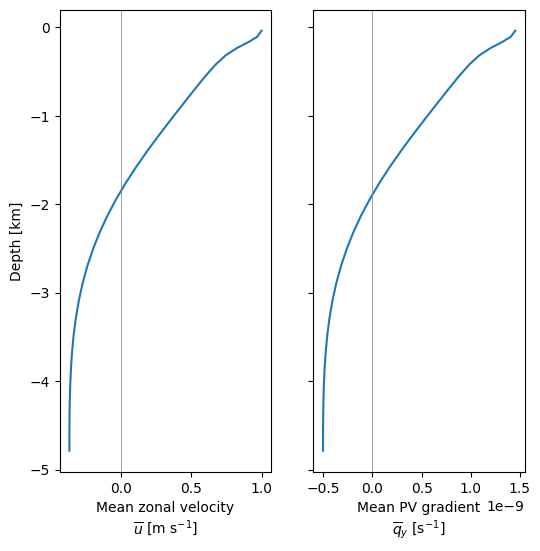

In [8]:
fig, ax = plt.subplots(1,2,figsize=(6,6),sharey=True)

beta = 2e-11

ax[0].plot(u_bar,(zc-1)*Htot/1e3)
ax[1].plot(qy_bar+beta,(zc-1)*Htot/1e3)
    
ax[0].axvline(color='grey',lw=0.5)
ax[1].axvline(color='grey',lw=0.5)

ax[0].set_ylabel('Depth [km]')
ax[0].set_xlabel('Mean zonal velocity\n'+r'$\overline{u}$ [m s$^{-1}$]')
ax[1].set_xlabel('Mean PV gradient\n'+r'$\overline{q}_y$ [s$^{-1}$]')

# Write stratification and grid files

Now write 

  (i)   the stratification function S = f^2/N^2(z) evaluated at interface heights
  
  (ii)  the layer thicknesses (h)
  
  (iii) the layer centers (zc)
  
  (iv) the mean flow profile (u_bar)
  
The indexing convention in the QGN model is left-handed, like most ocean models, i.e. the first index is at the top of the ocean and the last index is at the bottom of the ocean. This is the opposite of what has been used through the notebook, so flip arrays before writing so that they are written from top of the column (z=1) to the bottom (z=0).

In [11]:
assert (zi[-1] == 1) & (zi[0] == 0) ## confirm ordering and that zi span the nondimensionalized [0,1] column before flipping

np.flip(1/N2(zi)).tofile(savedir+"S.dat")

np.flip(h).tofile(savedir+"H.dat")

np.flip(zc).tofile(savedir+"zc.dat")

np.flip(u_bar).tofile(savedir+"UBar.dat")  

# Some setup diagnostics (optional)

## Baroclinic radii and modes

[28.62076273 15.56656366 10.73274899  7.89853565  6.26237792  5.2355234
  4.52323145  3.99451247  3.58979193  3.27383574  3.02270472  2.8204653
  2.65709466  2.52866234  2.42728004  2.33423314  2.24706614  2.15339363
  2.04397745  1.92182817  1.7894061   1.64816005  1.49919845  1.34347474
  1.18185296  1.0151407   0.84411276  0.66954623  0.4923208   0.31373227
  0.13627084]


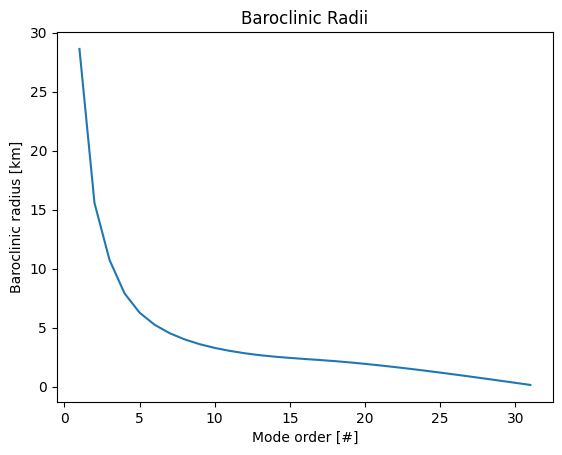

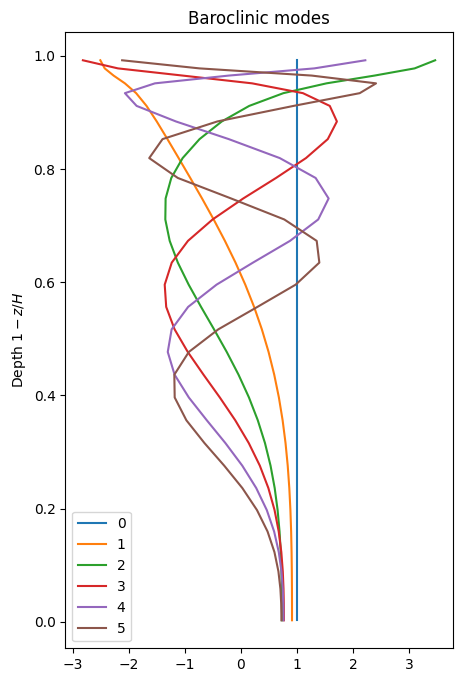

In [10]:
evals, evecs, L = strat.get_modes(zi,h,N2)
bc_radii = Htot*(1/np.sqrt(-evals[1:]))/1e3
print(bc_radii)

plt.figure()
plt.title('Baroclinic Radii')
plt.plot(np.arange(1,nz),bc_radii)
plt.xlabel('Mode order [#]')
plt.ylabel('Baroclinic radius [km]')

plt.figure(figsize=(5,8))
plt.title('Baroclinic modes')
for n in range(0,6):
    plt.plot(evecs[:,n],zc,label='%d'%n)

plt.ylabel(r'Depth $1-z/H$')
plt.legend()


## Baroclinic instability and growth rates (optional)

In [11]:
def get_AB(kx,u_bar,qy_bar,beta,ell):
    # The QG linear baroclinic instability problem can be written as c B p = A p where p is an
    # eigenvector of psi values, A and B are matrices, c is the eigenvalue, and the real part of 
    # -i kx c is the growth rate. The A and B matrices depend on the wavenumber kx (this  code
    # assumes ky=0) and on beta, and they use the values of L, u_bar, and qy_bar.
    
    B = (kx**2) * np.eye(ell.shape[0]) - ell/(Htot**2)
    A = np.diag(u_bar)@B - np.diag(qy_bar + beta)
    return A, B

def get_growth_rate(k,zi,h,N2,ubar,qybar):

    import scipy.linalg as linalg

    growth_rate = np.zeros((k.shape[0]))

    evals, evecs, L = strat.get_modes(zi,h,N2)
    
    for i in range(k.shape[0]):
        (A, B) = get_AB(k[i],ubar,qybar,2E-11,L)
        c = linalg.eigvals(A,B)
        growth_rate[i] = k[i]*np.max(np.imag(c))

    return growth_rate

In [12]:
# Set a range of horizontal wave numbers; the right endpoint is empirical. It should be about 5 times the
# deformation wavenumber in order to see the main instability. Taking a larger value can show spurious
# instabilities that may develop at small scales. 
k = np.linspace(0,0.000125,1001) 

growth_rate = get_growth_rate(k,zi,h,N2,u_bar,qy_bar)

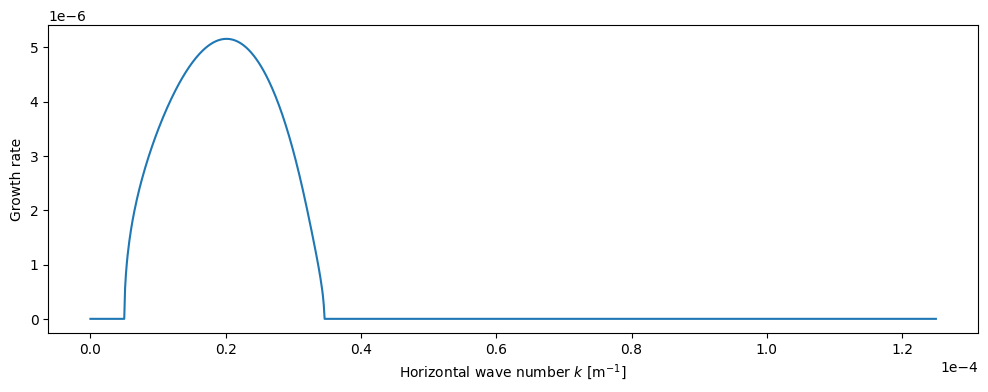

In [13]:
fig, ax = plt.subplots(1,1,figsize=(12,4),sharex=True)

ax.plot(k,growth_rate)
        
ax.set_xlabel(r'Horizontal wave number $k$ [m$^{-1}$]')
ax.set_ylabel(r'Growth rate')
ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))